# Byte Beads — Bebras (distal) and Day 2 proximal analysis

Step-by-step exploratory data analysis followed by statistics for a computational-thinking
intervention at Southwest Middle School (n=30, grades 7-8, one intact class, **no control group**).

**Design.** Students played the Byte Beads game between a Bebras pretest and posttest.
- **Distal** Bebras CT test at three times: pre (Apr 30), post (May 7), delayed (May 14).
- **Proximal** in-game Day 2 task (May 5): Part A objective, Parts B/C open + coded.

**Read the limitations cell before interpreting anything.**

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import load
import stats as st

sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "outputs" / "figures"
TAB = Path.cwd().parent / "outputs" / "tables"
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)

data = load.load_json()
totals = load.load_distal_totals(data)
long = load.load_distal_long(data)
prox = load.load_proximal(data)
mrg = load.merged(data)
print("students:", data["n_students"])

students: 30


## Limitations (fixed — do not interpret results without these)

1. **Identical pre/post items.** Q1-Q5 are the *same questions* pre and post, so the pre-post
   gain blends real learning with retest/practice effects. The novel Q6 probe is the cleaner
   transfer signal.
2. **Delayed parallel form is not validated as equivalent.** Delayed accuracy collapses on
   Q1/Q3/Q4 (floor) while Q2 stays 100% and Q5 rises — a form-difficulty artifact, **not**
   forgetting. Delayed comparisons are reported for completeness only.
3. **No control group, n=30, single class.** Findings are descriptive/exploratory, not causal.

## 1. EDA

### 1.1 Sample counts and missingness

In [2]:
valid = long.groupby("phase", observed=True)["is_valid_response"].agg(["sum", "count"])
valid["n_absent_items"] = valid["count"] - valid["sum"]
# students with a usable total per phase
for col in ["pre_total", "post_total", "del_total"]:
    print(col, "valid students:", totals[col].notna().sum())
valid

pre_total valid students: 27
post_total valid students: 26
del_total valid students: 30


,sum,count,n_absent_items
phase,,,
pre,126,150,24
post,126,150,24
delayed,146,150,4


### 1.2 Distribution of pre / post / delayed totals

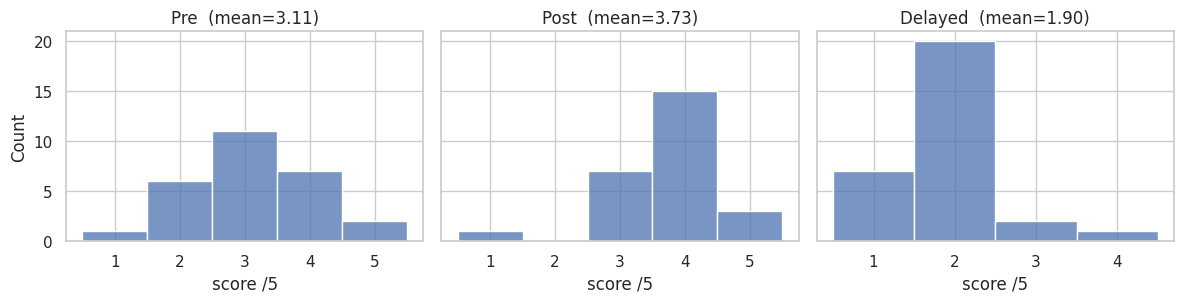

,pre_total,post_total,del_total
count,27.00,26.00,30.00
mean,3.11,3.73,1.90
std,0.97,0.83,0.66
min,1.00,1.00,1.00
25%,2.50,3.00,2.00
50%,3.00,4.00,2.00
75%,4.00,4.00,2.00
max,5.00,5.00,4.00


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for a, col, title in zip(ax, ["pre_total", "post_total", "del_total"], ["Pre", "Post", "Delayed"]):
    sns.histplot(totals[col].dropna(), bins=range(0, 7), ax=a, discrete=True)
    a.set_title(f"{title}  (mean={totals[col].mean():.2f})"); a.set_xlabel("score /5")
plt.tight_layout(); plt.savefig(FIG / "total_distributions.png", dpi=120); plt.show()
totals[["pre_total","post_total","del_total"]].describe().round(2)

### 1.3 Item-level % correct by phase (watch the delayed floor effect)

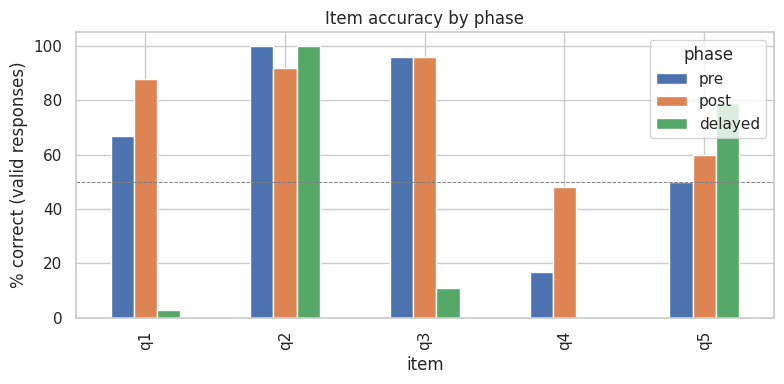

phase,pre,post,delayed
item,,,
q1,67.0,88.0,3.0
q2,100.0,92.0,100.0
q3,96.0,96.0,11.0
q4,17.0,48.0,0.0
q5,50.0,60.0,79.0


In [4]:
acc = (long.groupby(["phase", "item"], observed=True)
            .apply(lambda g: g.loc[g.is_valid_response, "correct"].mean(), include_groups=False)
            .unstack("phase"))[["pre", "post", "delayed"]]
acc_pct = (acc * 100).round(0)
acc_pct.to_csv(TAB / "item_accuracy_by_phase.csv")

ax = acc_pct.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("% correct (valid responses)"); ax.set_title("Item accuracy by phase")
ax.axhline(50, color="grey", lw=0.7, ls="--")
plt.tight_layout(); plt.savefig(FIG / "item_accuracy_by_phase.png", dpi=120); plt.show()
acc_pct

The delayed bars for Q1/Q3/Q4 sit near the floor while Q2 stays at ceiling — the signature
of a non-equivalent parallel form, consistent with limitation 2.

### 1.4 Novel probe (Q6) pass rates

In [5]:
probe = pd.DataFrame({
    "post_q6": [totals["post_q6_novel"].mean()],
    "del_q6":  [totals["del_q6_novel"].mean()],
    "n_post":  [totals["post_q6_novel"].notna().sum()],
    "n_del":   [totals["del_q6_novel"].notna().sum()],
})
probe.round(2)

,post_q6,del_q6,n_post,n_del
0,0.13,0.67,23,27


### 1.5 Proximal (Day 2) distributions and coding frequencies

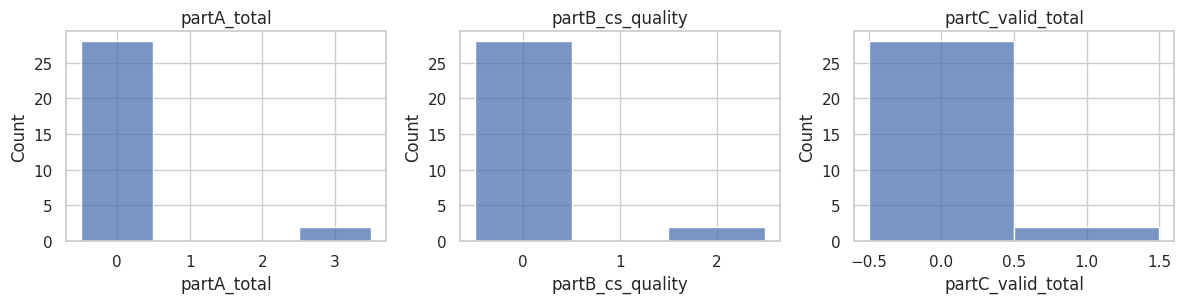

cs_idea_code frequency:
 Series([], Name: count, dtype: int64)


,partA_total,partB_cs_quality,partC_valid_total
count,30.00,30.00,30.00
mean,0.20,0.13,0.07
std,0.76,0.51,0.25
min,0.00,0.00,0.00
25%,0.00,0.00,0.00
50%,0.00,0.00,0.00
75%,0.00,0.00,0.00
max,3.00,2.00,1.00


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
for a, col in zip(ax, ["partA_total", "partB_cs_quality", "partC_valid_total"]):
    sns.histplot(prox[col].dropna(), ax=a, discrete=True); a.set_title(col)
plt.tight_layout(); plt.savefig(FIG / "proximal_distributions.png", dpi=120); plt.show()

codes = pd.concat([prox["b1_cs_idea_code"], prox["b2_cs_idea_code"]]).dropna()
print("cs_idea_code frequency:\n", codes.value_counts())
prox[["partA_total","partB_cs_quality","partC_valid_total"]].describe().round(2)

## 2. Statistics

### 2.1 Reliability of the 5-item scale (KR-20)

The pre-test items form the scale; KR-20 tells us how internally consistent the 5 binary items are
before we trust totals. A 5-item test rarely exceeds ~0.7, so read this as a floor caveat, not a verdict.

In [7]:
pre_items = (long[long.phase == "pre"]
             .pivot(index="student_id", columns="item", values="correct"))
print("KR-20 (pre, complete cases):", round(st.kr20(pre_items), 3))

KR-20 (pre, complete cases): 0.633


### 2.2 Primary test — Pre → Post total (Q1-Q5)

Same students measured twice, bounded discrete 0-5 scores → **paired t-test** with **Wilcoxon
signed-rank** as the distribution-free check, plus **Cohen's dz** and a 95% CI. This is the main
learning measure (with the retest caveat from limitation 1).

In [8]:
r = st.paired_change(totals["pre_total"], totals["post_total"])
print(f"n={r['n']}  mean diff={r['mean_diff']:+.2f}  95% CI [{r['ci95'][0]:.2f}, {r['ci95'][1]:.2f}]")
print(f"t={r['t']:.2f}  p(t)={r['p_ttest']:.3f}  p(Wilcoxon)={r['p_wilcoxon']:.3f}  Cohen dz={r['cohens_dz']:.2f}")

n=26  mean diff=+0.58  95% CI [0.08, 1.08]
t=2.38  p(t)=0.026  p(Wilcoxon)=0.027  Cohen dz=0.47


### 2.3 Delayed comparisons (reported for completeness — see limitation 2)

In [9]:
for label, a, b in [("Pre->Delayed", "pre_total", "del_total"),
                    ("Post->Delayed", "post_total", "del_total")]:
    r = st.paired_change(totals[a], totals[b])
    print(f"{label}: n={r['n']} diff={r['mean_diff']:+.2f} p(t)={r['p_ttest']:.4f} dz={r['cohens_dz']:.2f}")
print("\nThese negative 'effects' reflect a harder, non-equivalent delayed form, not memory loss.")

Pre->Delayed: n=27 diff=-1.15 p(t)=0.0000 dz=-1.08
Post->Delayed: n=26 diff=-1.73 p(t)=0.0000 dz=-1.66

These negative 'effects' reflect a harder, non-equivalent delayed form, not memory loss.


### 2.4 Item-level Pre → Post — McNemar exact test

Each item is binary and paired, so **McNemar's exact test** on the discordant pairs is the correct
per-item test. Family of 5 → **Holm-Bonferroni** correction.

In [10]:
wide = long.pivot_table(index="student_id", columns=["phase", "item"],
                        values="correct", observed=True)
rows, pvals = [], {}
for item in load.ITEMS:
    m = st.mcnemar(wide[("pre", item)], wide[("post", item)])
    rows.append({"item": item, **m}); pvals[item] = m["p_exact"]
adj = st.holm(pvals)
mc = pd.DataFrame(rows).set_index("item")
mc["p_holm"] = pd.Series(adj)
mc.round(3)

,n,gained_0to1,lost_1to0,p_exact,p_holm
item,,,,,
q1,30,7,4,0.549,1.000
q2,30,0,3,0.250,1.000
q3,30,4,2,0.688,1.000
q4,30,8,0,0.008,0.039
q5,30,6,3,0.508,1.000


### 2.5 Proximal → distal transfer — Spearman

The strongest test of transfer that isn't contaminated by identical items: does higher in-game
(proximal) performance predict a larger Bebras gain? Small n and ordinal measures → **Spearman**.

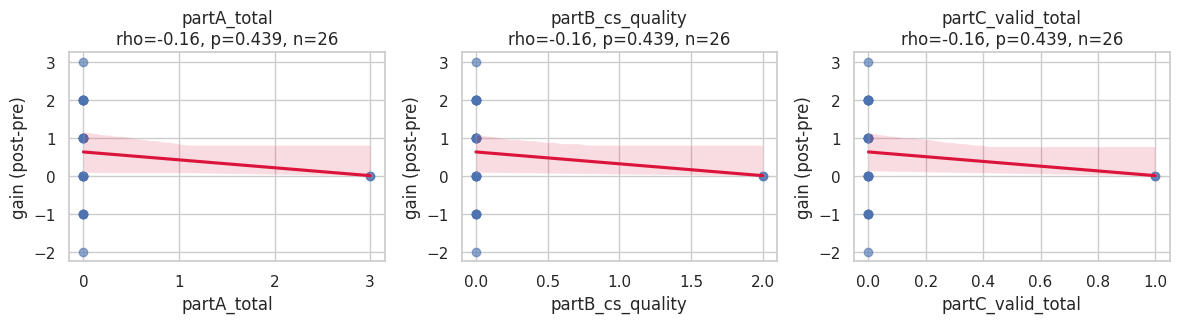

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for a, col in zip(ax, ["partA_total", "partB_cs_quality", "partC_valid_total"]):
    r = st.spearman(mrg[col], mrg["gain_post_pre"])
    sns.regplot(x=mrg[col], y=mrg["gain_post_pre"], ax=a,
                scatter_kws={"alpha": 0.6}, line_kws={"color": "crimson"})
    a.set_title(f"{col}\nrho={r['rho']:.2f}, p={r['p']:.3f}, n={r['n']}")
    a.set_ylabel("gain (post-pre)")
plt.tight_layout(); plt.savefig(FIG / "proximal_vs_gain.png", dpi=120); plt.show()

## 3. Results summary

In [12]:
summary = pd.DataFrame([
    {"comparison": "Pre->Post total", **{k: st.paired_change(totals.pre_total, totals.post_total)[k]
        for k in ["n", "mean_diff", "p_ttest", "cohens_dz"]}},
    {"comparison": "Pre->Delayed total", **{k: st.paired_change(totals.pre_total, totals.del_total)[k]
        for k in ["n", "mean_diff", "p_ttest", "cohens_dz"]}},
    {"comparison": "Post->Delayed total", **{k: st.paired_change(totals.post_total, totals.del_total)[k]
        for k in ["n", "mean_diff", "p_ttest", "cohens_dz"]}},
]).round(3)
summary.to_csv(TAB / "results_summary.csv", index=False)
summary

,comparison,n,mean_diff,p_ttest,cohens_dz
0,Pre->Post total,26,0.577,0.026,0.466
1,Pre->Delayed total,27,-1.148,0.000,-1.080
2,Post->Delayed total,26,-1.731,0.000,-1.662


### Interpretation

- **Pre → Post:** a small-to-medium, statistically detectable gain on the distal Bebras total,
  concentrated in the sequencing / pattern-rule items. Part of it is retest effect (identical items),
  so the novel probe and the proximal-transfer correlation carry the real transfer argument.
- **Delayed:** uninterpretable as retention — the parallel form is not equivalent. Validate or
  rescore the delayed form before making any durability claim.
- **Transfer:** the proximal→gain correlations are the cleanest evidence; interpret with the small n.

All limitations from the top cell stand.